In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# (da NewPerformanceMetric_Advanced2.ipynb, cell 42)
df_merged = pd.read_parquet(Path("data/derived/df_merged_ad2.parquet"))
df_merged.shape


(3464, 151)

In [2]:
df_merged.columns

Index(['index_home', 'team_name_home', 'n_pass_home', 'pass_acc_home',
       'n_prog_pass_home', 'n_shot_home', 'n_shot_ot_home', 'n_shot_box_home',
       'n_keypass_home', 'n_pressure_home',
       ...
       'attacking_share_away', 'recovery_high_away', 'recovery_mid_away',
       'recovery_low_away', 'counterpress_won_away', 'prog_pass_away',
       'prog_carry_away', 'dangerous_carry_away', 'switches_away',
       'verticality_away'],
      dtype='object', length=151)

In [3]:
df_final = pd.read_parquet("data/xg_dataset_oof.parquet")
#candidates = joblib.load("candidates.pkl")
print("✅ Ricaricato df_final")

✅ Ricaricato df_final


In [4]:
# 1️⃣ Crea una colonna binaria per il gol reale
df_final["goal"] = (df_final["shot_outcome_name"] == "Goal").astype(int)

# 2️⃣ Raggruppa per match e squadra
df_match_team = (
    df_final
    .groupby(["match_id", "team_name"], as_index=False)
    .agg(
        xG_sum=("xG_oof", "sum"),
        goals=("goal", "sum"),
        n_shots=("xG_oof", "count"),
    )
)


In [5]:
# Assumo queste colonne già pronte
# df_match_team: [match_id, team_name, xG_sum, goals, n_shots]

# 1) Totali per match
match_totals = (
    df_match_team
    .groupby("match_id", as_index=False)[["xG_sum", "goals"]]
    .sum()
    .rename(columns={"xG_sum": "xG_match_sum", "goals": "goals_match_sum"})
)

# 2) Aggiungi i totali a ciascuna riga (squadra)
df_mt = df_match_team.merge(match_totals, on="match_id", how="left")

# 3) Ricava i valori dell’avversario per differenza
df_mt["opp_xG_sum"] = df_mt["xG_match_sum"] - df_mt["xG_sum"]
df_mt["opp_goals"]  = df_mt["goals_match_sum"] - df_mt["goals"]

# 4) Differenze (prospettiva di ciascuna squadra)
df_mt["xG_diff_team"]   = df_mt["xG_sum"]   - df_mt["opp_xG_sum"]
df_mt["goal_diff_team"] = df_mt["goals"]    - df_mt["opp_goals"]

MATCH_COL = "match_id"
TEAM_COL  = "team_name"

df_ord = df_match_team.sort_values([MATCH_COL, TEAM_COL]).copy()
df_ord["ab_idx"] = df_ord.groupby(MATCH_COL).cumcount()

A = (df_ord[df_ord["ab_idx"] == 0]
     [[MATCH_COL, TEAM_COL, "xG_sum", "goals"]]
     .rename(columns={TEAM_COL:"team_A","xG_sum": "xG_A", "goals": "goals_A"}))

B = (df_ord[df_ord["ab_idx"] == 1]
     [[MATCH_COL, TEAM_COL, "xG_sum", "goals"]]
     .rename(columns={TEAM_COL:"team_B","xG_sum": "xG_B", "goals": "goals_B"}))

df_home_away = (A.merge(B, on=MATCH_COL, how="inner")
                  .assign(
                      xG_diff   = lambda d: d["xG_A"] - d["xG_B"],
                      goal_diff = lambda d: d["goals_A"] - d["goals_B"]
                  ))


# 6) Metriche sintetiche
import numpy as np
acc = (np.sign(df_home_away["xG_diff"]) == np.sign(df_home_away["goal_diff"])).mean()
corr = df_home_away[["xG_diff", "goal_diff"]].corr().iloc[0,1]

print(f"Correlazione xG_diff vs goal_diff: {corr:.3f}")
print(f"% match 'predetti' dagli xG: {acc:.1%}")


Correlazione xG_diff vs goal_diff: 0.710
% match 'predetti' dagli xG: 61.1%


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

def oof_xg_match(df_home_away, seed=42):
    df_match = df_home_away.copy()
    df_match["xG_diff"] = df_match["xG_A"] - df_match["xG_B"]
    df_match["abs_xG_diff"] = df_match["xG_diff"].abs()
    df_match["xG_sum"] = df_match["xG_A"] + df_match["xG_B"]
    df_match["result"] = np.sign(df_match["goals_A"] - df_match["goals_B"]).astype(int)  # -1,0,1

    f_draw = ["abs_xG_diff", "xG_sum"]
    f_win  = ["xG_diff", "xG_sum"]

    base_draw = LogisticRegression(class_weight="balanced", max_iter=2000, solver="saga", random_state=seed)
    base_win  = LogisticRegression(class_weight="balanced", max_iter=2000, solver="saga", random_state=seed)

    cal_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

    clf_draw = CalibratedClassifierCV(estimator=base_draw, method="isotonic", cv=cal_cv)
    clf_win  = CalibratedClassifierCV(estimator=base_win,  method="isotonic", cv=cal_cv)

    y = df_match["result"].values
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    p_draw_oof = np.zeros(len(df_match))
    p_win_oof  = np.zeros(len(df_match))
    p_loss_oof = np.zeros(len(df_match))
    y_pred_oof = np.zeros(len(df_match), dtype=int)

    for tr_idx, va_idx in cv.split(df_match, y):
        df_tr = df_match.iloc[tr_idx]
        df_va = df_match.iloc[va_idx]

        y_draw_tr = (df_tr["result"] == 0).astype(int)
        clf_draw.fit(df_tr[f_draw], y_draw_tr)
        p_draw_va = clf_draw.predict_proba(df_va[f_draw])[:, 1]

        mask_nd_tr = df_tr["result"] != 0
        y_win_tr = (df_tr.loc[mask_nd_tr, "result"] == 1).astype(int)
        clf_win.fit(df_tr.loc[mask_nd_tr, f_win], y_win_tr)
        p_win_nd_va = clf_win.predict_proba(df_va[f_win])[:, 1]

        p_win_va  = (1 - p_draw_va) * p_win_nd_va
        p_loss_va = 1 - p_draw_va - p_win_va

        p_draw_oof[va_idx] = p_draw_va
        p_win_oof[va_idx]  = p_win_va
        p_loss_oof[va_idx] = p_loss_va

        probs_va = np.vstack([p_loss_va, p_draw_va, p_win_va]).T
        y_pred_oof[va_idx] = np.array([-1, 0, 1])[probs_va.argmax(axis=1)]

    return pd.DataFrame({
        "match_id": df_match["match_id"].values,
        "p_loss": p_loss_oof,
        "p_draw": p_draw_oof,
        "p_win":  p_win_oof,
        "pred":   y_pred_oof,
        "true":   y
    })


In [7]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

# mappa classi come fai altrove
class_map = {-1: 0, 0: 1, 1: 2}
inv_class = {0: -1, 1: 0, 2: 1}

def oof_event_based(df_merged, feature_cols, seed):
    y = df_merged["result_tri_home"].astype(int).values
    y_idx = np.array([class_map[v] for v in y])

    groups = df_merged["match_id"].astype(str).values  # no leakage intra-match
    gkf = GroupKFold(n_splits=5)

    p_oof = np.zeros((len(df_merged), 3))
    pred = np.zeros(len(df_merged), dtype=int)

    for tr, va in gkf.split(df_merged[feature_cols], y_idx, groups):
        X_tr = df_merged.iloc[tr][feature_cols]
        X_va = df_merged.iloc[va][feature_cols]
        y_tr = y_idx[tr]

        clf = LGBMClassifier(
            objective="multiclass",
            num_class=3,
            learning_rate=0.05,
            n_estimators=400,
            max_depth=-1,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=seed,
            verbosity=-1
        )
        clf.fit(X_tr, y_tr)
        p = clf.predict_proba(X_va)

        p_oof[va] = p
        pred[va] = p.argmax(axis=1)

    pred_tri = np.array([inv_class[i] for i in pred])

    out = df_merged[["match_id"]].copy()
    out["p_loss"] = p_oof[:, 0]
    out["p_draw"] = p_oof[:, 1]
    out["p_win"]  = p_oof[:, 2]
    out["pred"]   = pred_tri
    out["true"]   = y
    return out


In [8]:
df_xG = pd.read_parquet(Path("data/derived/df_xG.parquet"))
df_xG

,match_id,team_A,xG_A,goals_A,team_B,xG_B,goals_B,xG_diff,goal_diff,abs_xG_diff,xG_sum,result,p_loss_ev,p_draw_ev,p_win_ev,pred_result_ev
0,7430,North Carolina Courage,1.978849,4,Washington Spirit,1.275335,2,0.703514,2,0.703514,3.254184,1,0.174975,0.256791,0.568234,1
1,7443,OL Reign,1.880929,3,Portland Thorns,3.589765,2,-1.708836,1,1.708836,5.470694,1,0.906220,0.067876,0.025904,-1
2,7444,Chicago Red Stars,0.740094,1,North Carolina Courage,2.435871,1,-1.695777,0,1.695777,3.175965,0,0.826759,0.141227,0.032014,-1
3,7445,Utah Royals,0.845233,2,Washington Spirit,0.922957,0,-0.077724,2,0.077724,1.768190,1,0.261429,0.407308,0.331264,0
4,7451,North Carolina Courage,2.033903,1,Washington Spirit,0.820693,0,1.213209,1,1.213209,2.854596,1,0.068447,0.229594,0.701959,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2953,3942819,England,1.141363,2,Netherlands,0.323959,1,0.817403,1,0.817403,1.465322,1,0.140004,0.301839,0.558158,1
2954,3942852,Colombia,1.436105,1,Uruguay,0.955146,0,0.480958,1,0.480958,2.391251,1,0.189004,0.291254,0.519743,1
2955,3943043,England,0.404001,1,Spain,1.238682,2,-0.834681,-1,0.834681,1.642684,-1,0.554352,0.282291,0.163357,-1
2956,3943076,Canada,5.346318,5,Uruguay,4.037971,6,1.308347,-1,1.308347,9.384290,-1,0.061866,0.010686,0.927448,1


In [9]:
df_xG["match_id"]     = df_xG["match_id"].astype(str)

# Ora il merge funziona
df_merged = df_merged.merge(
    df_xG[["match_id", "xG_A", "xG_B"]],
    on="match_id",
    how="left"
)

In [10]:
df_merged

,index_home,team_name_home,n_pass_home,pass_acc_home,n_prog_pass_home,n_shot_home,n_shot_ot_home,n_shot_box_home,n_keypass_home,n_pressure_home,...,recovery_mid_away,recovery_low_away,counterpress_won_away,prog_pass_away,prog_carry_away,dangerous_carry_away,switches_away,verticality_away,xG_A,xG_B
0,0,Barcelona,917,0.894220,243,25,9,18,16,70,...,7,20,0,87,21,7,8,0.664569,2.881130,0.264819
1,2,Barcelona,628,0.835987,219,11,5,7,8,88,...,14,23,0,110,29,15,14,0.567752,0.826873,0.301977
2,4,Barcelona,701,0.907275,213,30,15,21,22,80,...,5,13,0,90,24,13,5,0.532781,4.314663,1.107642
3,6,Barcelona,783,0.869732,227,12,6,9,9,112,...,9,14,0,95,28,11,8,0.512752,1.326573,0.856557
4,8,Barcelona,765,0.909804,177,21,10,10,16,114,...,7,15,0,94,21,6,18,0.491921,1.724242,1.217625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3459,6918,Barcelona,537,0.798883,171,14,6,9,10,204,...,4,11,0,114,55,26,15,0.454875,2.190718,2.831715
3460,6920,Barcelona,736,0.884511,222,21,9,14,18,96,...,6,14,0,103,33,12,22,0.472481,3.494396,2.360884
3461,6922,Barcelona,581,0.865749,161,11,4,9,8,90,...,8,7,0,107,46,18,36,0.378024,1.263421,1.746455
3462,6924,Barcelona,666,0.881381,219,13,6,7,8,157,...,5,17,0,103,43,22,12,0.412622,3.226477,1.142501


In [11]:
exclude_cols = [
    "goals_home","opp_goals_home","goal_diff_team_home",
    "result_bin_home","result_tri_home","goals_y_home","goals_match_sum_home",
    "goals_away","opp_goals_away","goal_diff_team_away",
    "result_bin_away","result_tri_away","goals_y_away","goals_match_sum_away", "xG_A", "xG_B"
]

# feature "event" = tutte tranne exclude e object
FEAT_EVENT = [c for c in df_merged.columns if c not in exclude_cols and df_merged[c].dtype != "object"]

# feature “combined”: qui aggiungi esplicitamente le colonne xG team-level (nomi tuoi)
XG_TEAM_COLS = [c for c in df_merged.columns if c.startswith("xG_") or c in ["xG_sum_home","xG_sum_away","xg_per_shot_home","xg_per_shot_away"]]
FEAT_COMBINED = sorted(list(set(FEAT_EVENT) | set(XG_TEAM_COLS)))

len(FEAT_EVENT), len(FEAT_COMBINED)


(132, 134)

In [12]:
import pandas as pd

def pts_from_pred_home_tri(pred_series):
    # pred: -1=home lose, 0=draw, 1=home win
    home_pts = np.select([pred_series == 1, pred_series == 0, pred_series == -1],
                         [3, 1, 0], default=np.nan)
    away_pts = np.select([pred_series == 1, pred_series == 0, pred_series == -1],
                         [0, 1, 3], default=np.nan)
    return home_pts, away_pts



def build_df_tm_from_oof(df_home_away, oof_event, oof_combined):
    base = df_home_away.copy()
    base["match_id"] = base["match_id"].astype(str)

    oof_event = oof_event.copy()
    oof_event["match_id"] = oof_event["match_id"].astype(str)

    oof_combined = oof_combined.copy()
    oof_combined["match_id"] = oof_combined["match_id"].astype(str)

    # merge per avere proba su ogni match
    m = base.merge(
        oof_event[["match_id","p_loss","p_draw","p_win", "pred"]].rename(columns={
            "p_loss":"p_loss_ev", "p_draw":"p_draw_ev", "p_win":"p_win_ev", "pred" : "pred_ev"
        }),
        on="match_id", how="left"
    ).merge(
        oof_combined[["match_id","p_loss","p_draw","p_win", "pred"]].rename(columns={
            "p_loss":"p_loss_cb", "p_draw":"p_draw_cb", "p_win":"p_win_cb", "pred" : "pred_cb"
        }),
        on="match_id", how="left"
    )

    # expected points per match (home/away)
    m["xPts_home_ev"], m["xPts_away_ev"] = pts_from_pred_home_tri(m["pred_ev"])
    m["xPts_home_cb"], m["xPts_away_cb"] = pts_from_pred_home_tri(m["pred_cb"])

    # esplodi in team×match (2 righe per match) -> df_tm
    cols_meta = ["match_id", "competition_name", "season_name"]
    cols_meta = [c for c in cols_meta if c in m.columns]  # safe

    home_rows = pd.DataFrame({
        **{c: m[c].values for c in cols_meta},
        "team_name": m["team_A"].values,
        "xPts_events_eb": m["xPts_home_ev"].values,
        "xPts_events": m["xPts_home_cb"].values,
    })

    away_rows = pd.DataFrame({
        **{c: m[c].values for c in cols_meta},
        "team_name": m["team_B"].values,
        "xPts_events_eb": m["xPts_away_ev"].values,
        "xPts_events": m["xPts_away_cb"].values,
    })

    df_tm = pd.concat([home_rows, away_rows], ignore_index=True)
    
    df = df_merged.copy()
    
    home_rows = df[[
        "match_id", "competition_name_home", "season_name_home",
        "team_name_home"
    ]].rename(columns={
        "competition_name_home": "competition_name",
        "season_name_home": "season_name",
        "team_name_home": "team_name"
    })

    away_rows = df[[
        "match_id", "competition_name_home", "season_name_home",
        "team_name_away"
    ]].rename(columns={
        "competition_name_home": "competition_name",
        "season_name_home": "season_name",
        "team_name_away": "team_name"
    })

    df_tm2 = pd.concat([home_rows, away_rows], ignore_index=True)
    
    df_tm = df_tm.merge(df_tm2[["match_id", "competition_name", "season_name"]], on = "match_id", how = "left")

    return df_tm


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

SEEDS = [100 + i for i in range(10)]  # scegli tu

rows = []

for seed in SEEDS:
    # =========================================
    # (A) match-level: xG -> outcome probabilities (OOF)
    # =========================================
    xg_oof = oof_xg_match(df_home_away, seed=seed)
    xg_oof["match_id"] = xg_oof["match_id"].astype(str)

    df_xg_seed = df_home_away.copy()
    df_xg_seed["match_id"] = df_xg_seed["match_id"].astype(str)

    df_xg_seed = df_xg_seed.merge(
        xg_oof[["match_id","p_win","p_draw","p_loss", "pred"]],
        on="match_id",
        how="left"
    )
    
    oof_event = oof_event_based(df_merged, FEAT_EVENT, seed)
    
    oof_combined = oof_event_based(df_merged, FEAT_COMBINED, seed)
    
    df_tm = build_df_tm_from_oof(df_home_away, oof_event, oof_combined)

    # =========================================
    # (B) team×match: replica identica al tuo codice
    # =========================================
    dx = df_xg_seed.copy()
    de = df_tm.copy()

    dx["match_id"] = dx["match_id"].astype(str)
    de["match_id"] = de["match_id"].astype(str)

    # 1) espando df_xg_seed a livello TEAM
    rows_team = []
    for r in dx.itertuples():
        # punti reali
        if r.goals_A > r.goals_B:
            pts_A, pts_B = 3, 0
        elif r.goals_A < r.goals_B:
            pts_A, pts_B = 0, 3
        else:
            pts_A, pts_B = 1, 1

        # expected points da xG outcome model
        ep_A = np.select([
            r.pred == 1,
            r.pred == 0,
            r.pred == -1],
            [3, 1, 0],
            default=np.nan
        ).astype(float)

        ep_B = np.select(
            [r.pred == 1,
            r.pred == 0,
            r.pred == -1],
            [0, 1, 3],
            default=np.nan
        ).astype(float)

        rows_team.append({"match_id": r.match_id, "team_name": r.team_A, "real_points": pts_A, "EP_xg": ep_A})
        rows_team.append({"match_id": r.match_id, "team_name": r.team_B, "real_points": pts_B, "EP_xg": ep_B})

    df_xg_team = pd.DataFrame(rows_team)

    # 2) prendo da df_tm i punti attesi event-based / combined (qui adatta i nomi colonna)
    df_ev_team = (
        de[["match_id","team_name","xPts_events_eb","xPts_events","competition_name","season_name"]]
        .drop_duplicates(["match_id","team_name"])
        .copy()
    )

    # 3) merge
    df_team_seed = df_xg_team.merge(df_ev_team, on=["match_id","team_name"], how="inner")

    # =========================================
    # (C) metriche global + per competition
    # =========================================
    # GLOBAL
    rows.append({
        "seed": seed,
        "competition": "GLOBAL",
        "RMSE_xG": root_mean_squared_error(df_team_seed["real_points"], df_team_seed["EP_xg"]),
        "RMSE_Event": root_mean_squared_error(df_team_seed["real_points"], df_team_seed["xPts_events_eb"]),
        "RMSE_Combined": root_mean_squared_error(df_team_seed["real_points"], df_team_seed["xPts_events"]),
        "MAE_xG": mean_absolute_error(df_team_seed["real_points"], df_team_seed["EP_xg"]),
        "MAE_Event": mean_absolute_error(df_team_seed["real_points"], df_team_seed["xPts_events_eb"]),
        "MAE_Combined": mean_absolute_error(df_team_seed["real_points"], df_team_seed["xPts_events"]),
    })

    # PER COMPETITION
    for comp, g in df_team_seed.groupby("competition_name"):
        rows.append({
            "seed": seed,
            "competition": comp,
            "RMSE_xG": root_mean_squared_error(g["real_points"], g["EP_xg"]),
            "RMSE_Event": root_mean_squared_error(g["real_points"], g["xPts_events_eb"]),
            "RMSE_Combined": root_mean_squared_error(g["real_points"], g["xPts_events"]),
            "MAE_xG": mean_absolute_error(g["real_points"], g["EP_xg"]),
            "MAE_Event": mean_absolute_error(g["real_points"], g["xPts_events_eb"]),
            "MAE_Combined": mean_absolute_error(g["real_points"], g["xPts_events"]),
        })

results = pd.DataFrame(rows)


In [14]:
results.columns

Index(['seed', 'competition', 'RMSE_xG', 'RMSE_Event', 'RMSE_Combined',
       'MAE_xG', 'MAE_Event', 'MAE_Combined'],
      dtype='object')

In [15]:
df_tm.columns

Index(['match_id', 'team_name', 'xPts_events_eb', 'xPts_events',
       'competition_name', 'season_name'],
      dtype='object')

In [16]:
results

,seed,competition,RMSE_xG,RMSE_Event,RMSE_Combined,MAE_xG,MAE_Event,MAE_Combined
0,100,GLOBAL,1.304476,1.154188,1.090171,0.741886,0.619168,0.573529
1,100,1. Bundesliga,1.343831,1.123283,1.013874,0.758824,0.573529,0.489706
2,100,African Cup of Nations,1.344504,1.362266,1.333734,0.807692,0.836538,0.836538
3,100,Champions League,1.433721,1.067187,1.224745,0.833333,0.416667,0.500000
4,100,Copa America,1.145644,1.369306,1.262438,0.562500,0.750000,0.656250
...,...,...,...,...,...,...,...,...
185,109,North American League,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
186,109,Premier League,1.379966,1.211488,1.096427,0.832536,0.685407,0.606459
187,109,Serie A,1.381828,1.159238,1.156404,0.830709,0.629921,0.625984
188,109,UEFA Euro,1.455214,1.252449,1.339447,0.941176,0.705882,0.794118


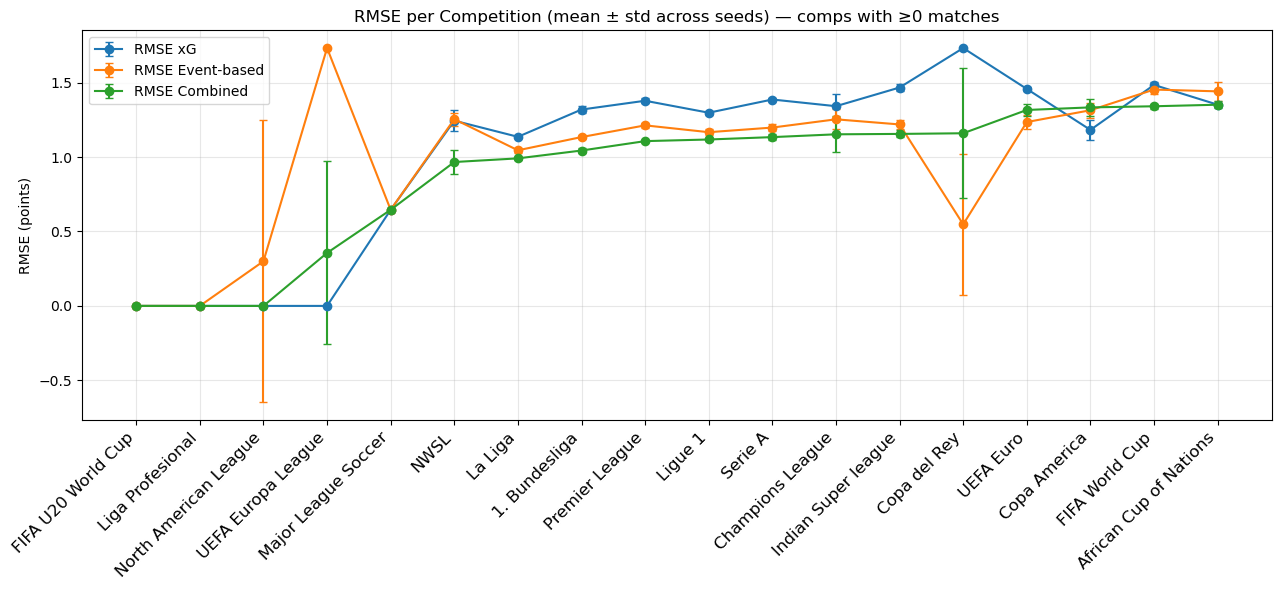

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

min_matches = 0

matches_by_comp = (df_tm.groupby("competition_name")["match_id"].nunique()
                   .rename("Matches")
                   .reset_index()
                   .rename(columns={"competition_name":"competition"}))

results = results.merge(matches_by_comp, on="competition", how="left")


# --- 0) tieni solo competition con >= min_matches (usando Matches) ---
comp_matches = (results[results["competition"] != "GLOBAL"]
                .groupby("competition")["Matches"]
                .max())  # è uguale per tutti i seed, max va bene

valid_comps = comp_matches[comp_matches >= min_matches].index

res_filt = results[(results["competition"].isin(valid_comps))].copy()

# --- 1) stats per competition: std tra seed ---
rmse_stats = (res_filt
              .groupby("competition")[["RMSE_xG","RMSE_Event","RMSE_Combined"]]
              .agg(["mean","std"]))
rmse_stats.columns = [f"{m}_{s}" for m, s in rmse_stats.columns]
rmse_stats = rmse_stats.reset_index()

# ordina per combined mean
rmse_stats = rmse_stats.sort_values("RMSE_Combined_mean").reset_index(drop=True)

# --- 2) plot con errorbar ---
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(rmse_stats))

ax.errorbar(x, rmse_stats["RMSE_xG_mean"], yerr=rmse_stats["RMSE_xG_std"],
            marker="o", capsize=3, label="RMSE xG")
ax.errorbar(x, rmse_stats["RMSE_Event_mean"], yerr=rmse_stats["RMSE_Event_std"],
            marker="o", capsize=3, label="RMSE Event-based")
ax.errorbar(x, rmse_stats["RMSE_Combined_mean"], yerr=rmse_stats["RMSE_Combined_std"],
            marker="o", capsize=3, label="RMSE Combined")

ax.set_xticks(x)
ax.set_xticklabels(rmse_stats["competition"], rotation=45, ha="right", fontsize=12)
ax.set_ylabel("RMSE (points)")
ax.set_title(f"RMSE per Competition (mean ± std across seeds) — comps with ≥{min_matches} matches")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig("rmse_competitions_seed_std_min50.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [18]:
rmse_stats

,competition,RMSE_xG_mean,RMSE_xG_std,RMSE_Event_mean,RMSE_Event_std,RMSE_Combined_mean,RMSE_Combined_std
0,FIFA U20 World Cup,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Liga Profesional,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,North American League,0.000000,0.000000,0.300000,0.948683,0.000000,0.000000
3,UEFA Europa League,0.000000,0.000000,1.732051,0.000000,0.355779,0.614716
4,Major League Soccer,0.645497,0.000000,0.645497,0.000000,0.645497,0.000000
5,NWSL,1.244332,0.070049,1.254325,0.043071,0.966468,0.083115
6,La Liga,1.135773,0.010553,1.045267,0.015231,0.991022,0.011219
7,1. Bundesliga,1.318914,0.022732,1.134074,0.014924,1.043723,0.019660
8,Premier League,1.378063,0.015802,1.212741,0.014603,1.106872,0.008994
9,Ligue 1,1.297692,0.012134,1.166843,0.021921,1.117818,0.012392


C:\Users\lucar\AppData\Local\Temp\ipykernel_13928\2142345810.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True, showfliers = False)


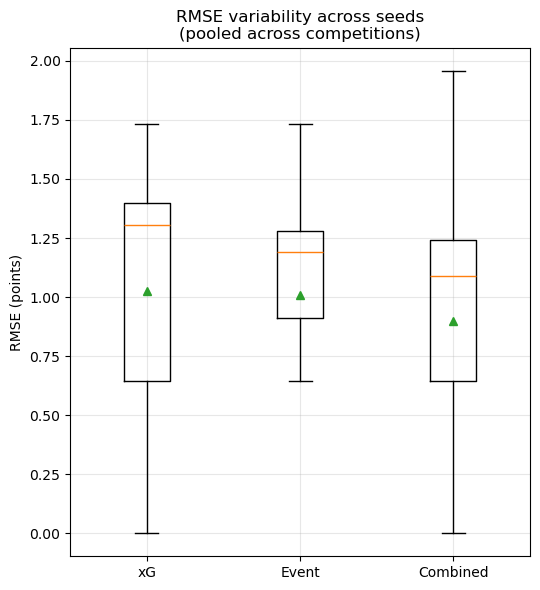

In [19]:
# tutti i punti (seed×competition) per modello
data = [
    results.loc[results["competition"]!="GLOBAL", "RMSE_xG"].values,
    results.loc[results["competition"]!="GLOBAL", "RMSE_Event"].values,
    results.loc[results["competition"]!="GLOBAL", "RMSE_Combined"].values
]

plt.figure(figsize=(5.5, 6))
plt.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True, showfliers = False)
plt.ylabel("RMSE (points)")
plt.title("RMSE variability across seeds\n(pooled across competitions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_seed_variability_boxplot.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\lucar\AppData\Local\Temp\ipykernel_13928\2640000211.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True, showfliers = False)


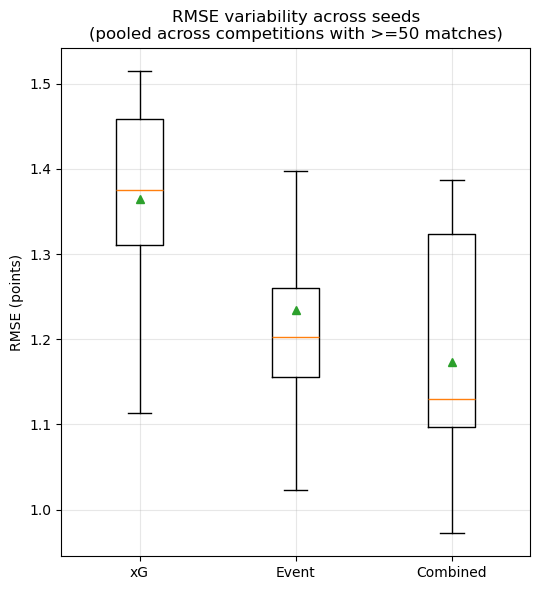

In [20]:
# --- Filter: keep only competitions with >= 50 matches (in df_team) ---
# df_team must have: match_id, competition_name
valid_comps = (
    df_team_seed.groupby("competition_name")["match_id"]
           .nunique()
           .loc[lambda s: s >= 50]
           .index
)

# --- violin data: all seed×competition points, but only valid competitions ---
mask = results["competition"].isin(valid_comps)

data = [
    results.loc[mask, "RMSE_xG"].values,
    results.loc[mask, "RMSE_Event"].values,
    results.loc[mask, "RMSE_Combined"].values
]

plt.figure(figsize=(5.5, 6))
plt.boxplot(data, labels=["xG", "Event", "Combined"], showmeans=True, showfliers = False)
plt.ylabel("RMSE (points)")
plt.title("RMSE variability across seeds\n(pooled across competitions with >=50 matches)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_seed_variability_boxplot.pdf", format="pdf", bbox_inches="tight")
plt.show()

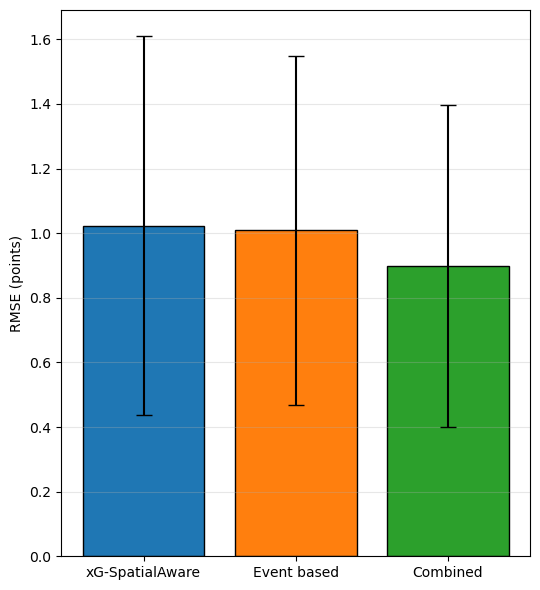

In [28]:
# pooled values (seed×competition) per modello
xg   = results.loc[results["competition"]!="GLOBAL", "RMSE_xG"].dropna().values
ev   = results.loc[results["competition"]!="GLOBAL", "RMSE_Event"].dropna().values
comb = results.loc[results["competition"]!="GLOBAL", "RMSE_Combined"].dropna().values

vals = [xg, ev, comb]
labels = ["xG-SpatialAware", "Event based", "Combined"]

means = [v.mean() for v in vals]
stds  = [v.std(ddof=1) for v in vals]  # sample std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # xG, Event, Combined

plt.figure(figsize=(5.5, 6))
x = np.arange(len(labels))

plt.bar(x, means, yerr=stds, capsize=6, color=colors, edgecolor="black",
        error_kw=dict(ecolor="black", lw=1.5))
plt.xticks(x, labels)
plt.ylabel("RMSE (points)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_seed_variability_barplot.pdf", bbox_inches="tight")
plt.show()


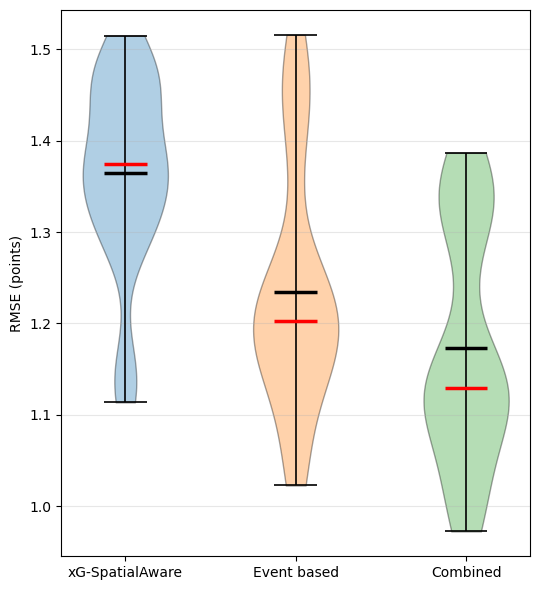

In [29]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

plt.figure(figsize=(5.5, 6))
vp = plt.violinplot(data, showmeans=True, showmedians=True, showextrema=True)

# Colora i violini (bodies)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.35)

# Colora media/mediana/estremi (se presenti)
vp["cmeans"].set_color("black")
vp["cmeans"].set_linewidth(2.5)

vp["cmedians"].set_color("red")
vp["cmedians"].set_linewidth(2.5)

for k in ["cbars", "cmins", "cmaxes"]:
    vp[k].set_color("black")
    vp[k].set_linewidth(1.2)

plt.xticks([1, 2, 3], labels)
plt.ylabel("RMSE (points)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_seed_variability_violin.pdf", bbox_inches="tight")
plt.show()


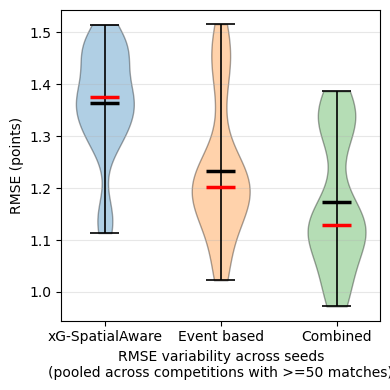

In [ ]:
# --- Filter: keep only competitions with >= 50 matches (in df_team) ---
# df_team must have: match_id, competition_name
valid_comps = (
    df_team_seed.groupby("competition_name")["match_id"]
           .nunique()
           .loc[lambda s: s >= 50]
           .index
)

# --- violin data: all seed×competition points, but only valid competitions ---
mask = results["competition"].isin(valid_comps)

data = [
    results.loc[mask, "RMSE_xG"].values,
    results.loc[mask, "RMSE_Event"].values,
    results.loc[mask, "RMSE_Combined"].values
]

plt.figure(figsize=(4, 4))
vp = plt.violinplot(data, showmeans=True, showmedians=True, showextrema=True)

# Colora i violini (bodies)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_edgecolor("black")
    body.set_alpha(0.35)

# Colora media/mediana/estremi (se presenti)
vp["cmeans"].set_color("black")
vp["cmeans"].set_linewidth(2.5)

vp["cmedians"].set_color("red")
vp["cmedians"].set_linewidth(2.5)

for k in ["cbars", "cmins", "cmaxes"]:
    vp[k].set_color("black")
    vp[k].set_linewidth(1.2)

plt.xticks([1, 2, 3], labels)
plt.xlabel("RMSE variability across seeds\n(pooled across competitions with >=50 matches)", fontsize = 10)
plt.ylabel("RMSE (points)", fontsize = 10)
plt.tick_params(axis="x", labelsize=10)
plt.tick_params(axis="y", labelsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rmse_seed_variability_violin50.pdf", bbox_inches="tight")
plt.show()
